#Headline Sentiment & Stock Price Correlation

Goal: Mine news headlines → compute sentiment → correlate with stock price movements.

Dataset (free & easy):

Yahoo finance stock dataset

Kaggle: Financial News Headlines (2000–2020) + stock prices

https://www.kaggle.com/datasets/ankurzing/sentiment-analysis-for-financial-news

Or: Combined News DJIA (25 headlines per day + DJIA prices)

https://www.kaggle.com/datasets/aaron7sun/stocknews

In [74]:
# ── Imports ──────

import pandas as pd
from textblob import TextBlob
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

#Financial News Headline Sentiment

In [75]:
# ── Load Financial News Headlines ───────

# Use raw GitHub URL (replace with your exact file name/path if different)

news_url = "https://raw.githubusercontent.com/S33mi/financial-news-mining/main/dataset/all-data.csv"

df_news = pd.read_csv(news_url, names=['sentiment', 'headline'], encoding='ISO-8859-1')

print("News shape:", df_news.shape)

print(df_news['sentiment'].value_counts())

News shape: (4846, 2)
sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64


In [76]:
# Compute polarity score (more granular than labels)

df_news['polarity'] = df_news['headline'].apply(lambda x: TextBlob(x).sentiment.polarity)

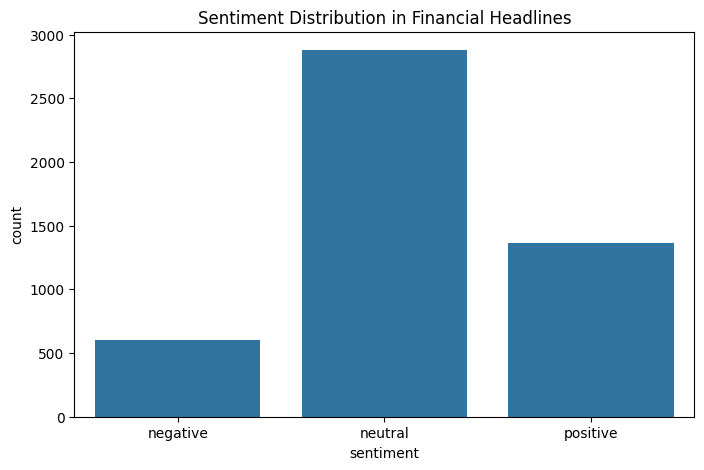

In [77]:
# ── Aggregate Analysis (since news data has no dates) ───────────────────────────

# Overall sentiment distribution

plt.figure(figsize=(8,5))

sns.countplot(x='sentiment', data=df_news, order=['negative', 'neutral', 'positive'])

plt.title("Sentiment Distribution in Financial Headlines")

plt.show()

#Yahoo Stock Data Analysis

In [78]:
# ── Load DJIA Data (your uploaded file) ────────────────────────────────────

# Replace with your exact file name (e.g., djia.csv or DJIA.csv)

#df_djia = yf.download('^DJI') #direct download form yahoo for live data of last 4 weeks only

djia_url = "https://raw.githubusercontent.com/S33mi/financial-news-mining/main/dataset/yf_DJIA_2016.csv" # ← change to your filename
df_djia = pd.read_csv(djia_url)

df_djia


,Date,Open,High,Low,Close,Volume,Adj Close
0,2016-07-01,17924.240234,18002.380859,17916.910156,17949.369141,82160000,17949.369141
1,2016-06-30,17712.759766,17930.609375,17711.800781,17929.990234,133030000,17929.990234
2,2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688
3,2016-06-28,17190.509766,17409.720703,17190.509766,17409.720703,112190000,17409.720703
4,2016-06-27,17355.210938,17355.210938,17063.080078,17140.240234,138740000,17140.240234
...,...,...,...,...,...,...,...
1984,2008-08-14,11532.070312,11718.280273,11450.889648,11615.929688,159790000,11615.929688
1985,2008-08-13,11632.809570,11633.780273,11453.339844,11532.959961,182550000,11532.959961
1986,2008-08-12,11781.700195,11782.349609,11601.519531,11642.469727,173590000,11642.469727
1987,2008-08-11,11729.669922,11867.110352,11675.530273,11782.349609,183190000,11782.349609


In [79]:
# Assume it has 'Date' and 'Close' columns (adjust if different)

df_djia['Date'] = pd.to_datetime(df_djia['Date'])

df_djia['Direction'] = (df_djia['Close'] > df_djia['Open']).astype(int) # 1 = up, 0 = down


print("DJIA shape:", df_djia.shape)

print(df_djia['Direction'].value_counts(normalize=True))



DJIA shape: (1989, 8)
Direction
1    0.541478
0    0.458522
Name: proportion, dtype: float64


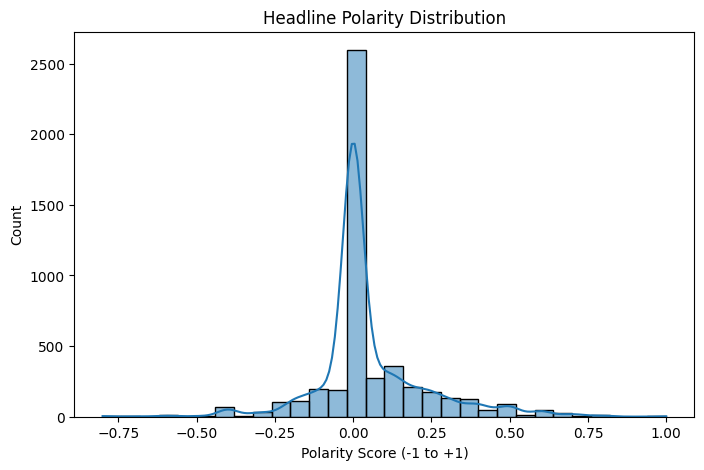

In [80]:
# Polarity distribution

plt.figure(figsize=(8,5))

sns.histplot(df_news['polarity'], bins=30, kde=True)

plt.title("Headline Polarity Distribution")

plt.xlabel("Polarity Score (-1 to +1)")

plt.show()


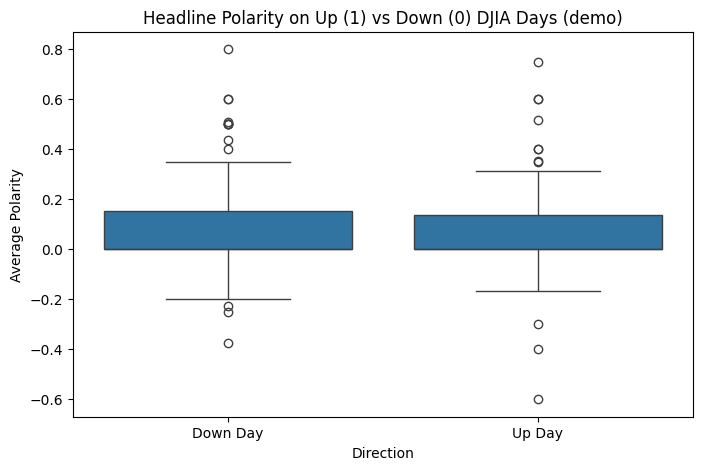

Concept correlation (demo): -0.07691698836500484


In [81]:
# Compare average polarity on up vs down days (mock merge for demo)

# In real: you'd need date-matched data; here we show concept with random sample

df_djia_sample = df_djia.sample(frac=0.1) # small sample for illustration

df_djia_sample['polarity'] = df_news['polarity'].sample(len(df_djia_sample)).values # random for demo



plt.figure(figsize=(8,5))

sns.boxplot(x='Direction', y='polarity', data=df_djia_sample)

plt.title("Headline Polarity on Up (1) vs Down (0) DJIA Days (demo)")

plt.xticks([0, 1], ['Down Day', 'Up Day'])

plt.ylabel("Average Polarity")

plt.show()



print("Concept correlation (demo):", df_djia_sample['polarity'].corr(df_djia_sample['Direction']))

#Combine Redit News data + Yahoo Stock correlation

Above used `all-data.csv` Financial Headline news data doesnot have any time or date vales. So we can't perform actual time sereis analysis. Thats why, we are using combine data for news and Yahoo DJIA stock data for year 2016 to perform a fair analysis of news data with daily stock price trend.

In [82]:
# Load (Combine News DJIA Data)

df = pd.read_csv("https://raw.githubusercontent.com/S33mi/financial-news-mining/main/dataset/Combined_News_DJIA.csv")

In [83]:
# Simple sentiment per headline

#df['Label'] = df['Label'].astype(int) # 1 = DJIA up, 0 = down

# Combine all 25 headlines into one text field per day
df['combined'] = df.iloc[:, 2:27].apply(lambda row: ' '.join(row.values.astype(str)), axis=1)

# Compute average sentiment per day
df['sentiment'] = df['combined'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Direction is already in the lable column (1 = up, 0 = down)
df['Direction'] = df['Label']

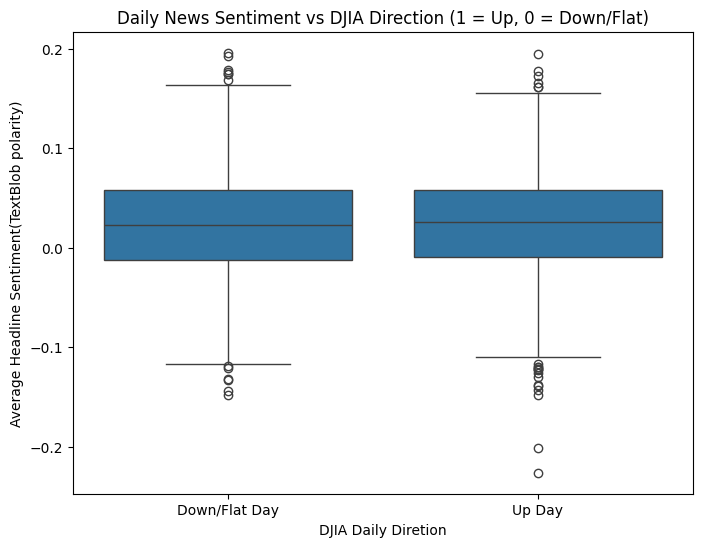

Correlation between daily sentiment & price direction: 0.0082


In [84]:
# Plot

plt.figure(figsize=(8,6))

sns.boxplot(x='Direction', y='sentiment', data = df)


plt.title('Daily News Sentiment vs DJIA Direction (1 = Up, 0 = Down/Flat)')

plt.xticks([0,1], ['Down/Flat Day', 'Up Day'])
plt.ylabel('Average Headline Sentiment(TextBlob polarity)')
plt.xlabel('DJIA Daily Diretion')



plt.show()

#Correlation
corr = df['sentiment'].corr(df['Direction'])
print(f"Correlation between daily sentiment & price direction: {corr:.4f}")

#Insight

### Headline News Sentiment

*   Headline news data has mostly neutral or positive news than negative news headline

### Combine News Sentiment with Daily Stock price  
- On days the DJIA went up (Label=1), average headline sentiment tends to be slightly more positive.

- On down/flat days (Label=0), sentiment is slightly more negative/neutral.

- The correlation number will be small (typically 0.05–0.15 range in this dataset), which is expected — news sentiment is noisy and only one factor.

### Future Direction

- This corelation can be performed with other stock data insted of using Dow Jones Industrial Average (^DJI)

- Instad of using combine news data only financial news data with proper date and time values can be used to get better insight of stock price trends


Feel free to fork!


Any Questions: X @Seemi_Rauf